# 🧬 Drug-Food Interaction Risk Assessment Pipeline for Oncology Drugs
### AI & Data Science Department

**Overview:**
This notebook systematically executes the Drug-Food Interaction risk assessment pipeline. It sequentially defines the necessary logic for each phase and immediately executes it, visualizing the outputs of each distinct step chronologically.


### Environment Setup & Data Simulation

* **What**: Imports required libraries and simulates a small real-world 5-row dataset locally if `clinical_interaction_real.csv` is not present globally.
* **Why**: To establish an initial testable baseline without assuming external infrastructure stability.
* **Expected Output**: A quietly generated `clinical_interaction_real.csv` bridging testing requirements.


In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests
import shap
import os
import time

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, DataStructs, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, roc_curve, 
                             mean_squared_error, mean_absolute_error, r2_score)
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report

%matplotlib inline

SEED = 42
np.random.seed(SEED)

csv_path = "clinical_interaction_real.csv"
if not os.path.exists(csv_path):
    print("Real dataset not found. Generating a 5-row mock DataFrame for testing...")
    dummy_data = {
        "Drug_Name": ["Imatinib", "Nilotinib", "Erlotinib", "Gefitinib", "Axitinib"],
        "Food_Name": ["Grapefruit", "Walnut", "Green Tea", "Garlic", "Grapefruit"],
        "Drug_SMILES": [
            "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CC=CC=C5",
            "CC1=C(C=C(C=C1)NC(=O)C2=CC(=CC(=C2)C(F)(F)F)N3C=CN=N3)NC4=NC=CC(=N4)C5=CC=CN=C5",
            "COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C)OCCOC",
            "COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OCCCN4CCOCC4",
            "CNC(=O)C1=CC=CC=C1SC2=CC3=C(C=C2)C(=NN3)C=CC4=CC=CC=N4"
        ],
        "Food_SMILES": [
            "CC(=CCCC(C)(C=C)O)C", "C1=CC=C(C=C1)C=CC(=O)O", "C1C(C(C(C(C1O)O)O)O)O", 
            "CSCC=C", "CC(=CCCC(C)(C=C)O)C"
        ],
        "interactions": [2, 1, 0, 1, 2],
        "Bioavail_Change_Pct": [25.5, -15.0, 2.0, 10.0, -35.5],
        "Drug_Class": ["TKI", "TKI", "EGFRi", "EGFRi", "VEGFRi"],
        "Split": ["train", "train", "unseen", "train", "unseen"],
        "fda_mentions_food": [1, 1, 0, 0, 1],
        "fda_interaction_keywords": [5, 2, 0, 1, 8]
    }
    pd.DataFrame(dummy_data).to_csv(csv_path, index=False)
    print(f"[{csv_path}] generated successfully.")
else:
    print(f"Found existing data file: {csv_path}")

Found existing data file: clinical_interaction_real.csv


### STEP 1: Data Acquisition

* **What**: Defines the loading architecture and immediately loads training vs unseen dataset partitions.
* **Why**: Establishes structural bounds early. Discards any pairs failing robust SMILES notation which would corrupt topology.
* **Expected Output**: A direct count output summarizing precisely how many Native interactions have survived structural ingestion, plus split mapping.


In [12]:
# ── Define Logic ──
def load_all_datasets(csv_path="clinical_interaction_real.csv") -> pd.DataFrame:
    """Dynamically load authentic data from a structured CSV, validating SMILES."""
    df_raw = pd.read_csv(csv_path)
    print(f"  [Load] Raw CSV contains {len(df_raw)} rows.")
    
    records = []
    for _, row in df_raw.iterrows():
        if pd.isna(row.get("Drug_SMILES", "")) or pd.isna(row.get("Food_SMILES", "")):
            continue
        records.append({
            "drug_name":   row["Drug_Name"],
            "food_name":   row["Food_Name"],
            "drug_smiles": row["Drug_SMILES"],
            "food_smiles": row["Food_SMILES"],
            "risk_level":  row["interactions"] if "interactions" in row else 0,
            "pct_change":  row["Bioavail_Change_Pct"],
            "drug_class":  row["Drug_Class"],
            "split":       row["Split"],
            "fda_mentions_food":      row.get("fda_mentions_food", 0),
            "fda_interaction_keywords": row.get("fda_interaction_keywords", 0),
        })
    return pd.DataFrame(records)

# ── Execute Step 1 ──
print("\n[STEP 1] Executing Data Acquisition...")
df_all = load_all_datasets(csv_path)
os.makedirs("./outputs", exist_ok=True)
df_all.to_csv("./outputs/raw_drug_food_dataset.csv", index=False)

df = df_all[df_all["split"] == "train"].copy()
unseen_df = df_all[df_all["split"] == "unseen"].copy()

print("\n  [Class Distribution — Train]")
for cls_val, cls_name in [(0, 'Neutral'), (1, 'Moderate'), (2, 'Critical')]:
    print(f"    {cls_name:10s}: {(df['risk_level'] == cls_val).sum()}")
    
print("  [Class Distribution — Unseen]")
for cls_val, cls_name in [(0, 'Neutral'), (1, 'Moderate'), (2, 'Critical')]:
    print(f"    {cls_name:10s}: {(unseen_df['risk_level'] == cls_val).sum()}")


[STEP 1] Executing Data Acquisition...
  [Load] Raw CSV contains 438 rows.

  [Class Distribution — Train]
    Neutral   : 118
    Moderate  : 118
    Critical  : 118
  [Class Distribution — Unseen]
    Neutral   : 28
    Moderate  : 28
    Critical  : 28


### STEP 2: Feature Engineering

* **What**: Deploys Morgan Fingerprints alongside standard RDKit descriptors and live API endpoints to extract physicochemical vectors for each row. 
* **Why**: Explicit machine learning boundaries cannot comprehend alphabetical strings. Fingerprints parse presence arrays while descriptors append macro scale biophysics (LogP, TPSA) making inference robust.
* **Expected Output**: An explicit iteration block querying APIs before finalizing high dimensional mapping sizes explicitly.


In [13]:
# ── Define Logic ──
def mol_from_smiles(smi: str):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: print(f"  [WARN] Invalid SMILES: {smi[:40]}…")
    return mol

def morgan_fingerprint(mol, radius: int = 2, n_bits: int = 1024) -> np.ndarray:
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = gen.GetFingerprint(mol)
    arr = np.zeros(n_bits, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def rdkit_descriptors(mol) -> dict:
    mw, logp, tpsa = Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol)
    hbd, hba = rdMolDescriptors.CalcNumHBD(mol), rdMolDescriptors.CalcNumHBA(mol)
    rotb, arom = rdMolDescriptors.CalcNumRotatableBonds(mol), rdMolDescriptors.CalcNumAromaticRings(mol)
    return {
        "MW": mw, "LogP": logp, "TPSA": tpsa, "HBD": hbd, "HBA": hba, "RotBonds": rotb,
        "AromaticRings": arom, "LogD": logp - (tpsa / 100.0),
        "Ro5_violations": sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    }

def tanimoto_similarity(fp_a: np.ndarray, fp_b: np.ndarray) -> float:
    intersect = np.sum(fp_a & fp_b)
    union = np.sum(fp_a | fp_b)
    return float(intersect / union) if union > 0 else 0.0

def fetch_pubchem_properties(smiles: str) -> dict:
    url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/property/MolecularWeight,XLogP,TPSA,HBondDonorCount,HBondAcceptorCount/JSON"
    try:
        resp = requests.post(url, data={"smiles": smiles}, timeout=8)
        if resp.status_code == 200:
            props = resp.json()["PropertyTable"]["Properties"][0]
            return {
                "MW_api": props.get("MolecularWeight", np.nan), "XLogP_api": props.get("XLogP", np.nan),
                "TPSA_api": props.get("TPSA", np.nan), "HBD_api": props.get("HBondDonorCount", np.nan),
                "HBA_api": props.get("HBondAcceptorCount", np.nan)
            }
    except: pass
    return {"MW_api": np.nan, "XLogP_api": np.nan, "TPSA_api": np.nan, "HBD_api": np.nan, "HBA_api": np.nan}

def build_feature_matrix(df_target: pd.DataFrame, fp_bits: int = 256) -> pd.DataFrame:
    drug_fps, food_fps, drug_descs, food_descs, tanimotos = [], [], [], [], []
    for _, row in df_target.iterrows():
        d_mol = mol_from_smiles(row["drug_smiles"]); f_mol = mol_from_smiles(row["food_smiles"])
        d_fp = morgan_fingerprint(d_mol, n_bits=fp_bits); f_fp = morgan_fingerprint(f_mol, n_bits=fp_bits)
        drug_fps.append(d_fp); food_fps.append(f_fp)
        drug_descs.append(rdkit_descriptors(d_mol)); food_descs.append(rdkit_descriptors(f_mol))
        tanimotos.append(tanimoto_similarity(d_fp, f_fp))

    drug_fp_df = pd.DataFrame(drug_fps, columns=[f"drug_fp_{i}" for i in range(fp_bits)])
    food_fp_df = pd.DataFrame(food_fps, columns=[f"food_fp_{i}" for i in range(fp_bits)])
    drug_desc_df = pd.DataFrame(drug_descs).add_prefix("drug_")
    food_desc_df = pd.DataFrame(food_descs).add_prefix("food_")

    print(f"  [API] Fetching real physicochemical properties from PubChem for {len(df_target)} rows...")
    drug_api, food_api, pc_cache = [], [], {}
    for _, row in df_target.iterrows():
        d_smi = row["drug_smiles"]; f_smi = row["food_smiles"]
        if d_smi not in pc_cache: pc_cache[d_smi] = fetch_pubchem_properties(d_smi); time.sleep(0.2)
        if f_smi not in pc_cache: pc_cache[f_smi] = fetch_pubchem_properties(f_smi); time.sleep(0.2)
        drug_api.append(pc_cache[d_smi]); food_api.append(pc_cache[f_smi])
        
    drug_api_df = pd.DataFrame(drug_api).add_prefix("drug_").apply(pd.to_numeric, errors='coerce').fillna(0.0)
    food_api_df = pd.DataFrame(food_api).add_prefix("food_").apply(pd.to_numeric, errors='coerce').fillna(0.0)
    tanimoto_df = pd.DataFrame({"tanimoto_similarity": tanimotos})

    fda_parts = [df_target[["fda_interaction_keywords"]].reset_index(drop=True).astype(float)] if "fda_interaction_keywords" in df_target.columns else []

    feat_df_out = pd.concat([drug_fp_df, food_fp_df, drug_desc_df.reset_index(drop=True), food_desc_df.reset_index(drop=True), drug_api_df.reset_index(drop=True), food_api_df.reset_index(drop=True), tanimoto_df] + fda_parts, axis=1)
    return feat_df_out

# ── Execute Step 2 ──
print("\n[STEP 2] Executing Feature Engineering on Train Set...")
feat_df = build_feature_matrix(df, fp_bits=256)
print(f"Train Matrix Shape: {feat_df.shape}")

print("\n[STEP 2] Executing Feature Engineering on Unseen Set...")
unseen_feat = build_feature_matrix(unseen_df, fp_bits=256)
print(f"Unseen Matrix Shape: {unseen_feat.shape}")

feat_names = feat_df.columns.tolist()


[STEP 2] Executing Feature Engineering on Train Set...
  [API] Fetching real physicochemical properties from PubChem for 354 rows...
Train Matrix Shape: (354, 542)

[STEP 2] Executing Feature Engineering on Unseen Set...
  [API] Fetching real physicochemical properties from PubChem for 84 rows...
Unseen Matrix Shape: (84, 542)


### STEP 3/4: Stratified Validation Splits & Data Selection

* **What**: Standardizes matrices, creates localized train/validation splits dynamically, and implements Recursive Feature Elimination (RFE) solely on the non-fingerprint descriptors.
* **Why**: RFE heavily mitigates noise across structural properties. However, mapping Morgan bit-vectors against RFE implies exponential time constraints and memory bottlenecks, therefore only localized descriptors are subject to filtering.
* **Expected Output**: A validation statement defining exactly how many dimensions persist into the ML modeling structure natively.


In [14]:
# ── Define Logic ──
def apply_rfe(X_mat: np.ndarray, y_vec: np.ndarray, n_features: int = 40) -> np.ndarray:
    """Recursive Feature Elimination using LogisticRegression."""
    if len(np.unique(y_vec)) <= 1:
        print("[WARN] Dataset lacks multi-class variance for structured RFE. Falling back implicitly.")
        return np.ones(X_mat.shape[1], dtype=bool)

    estimator = LogisticRegression(max_iter=500, solver="lbfgs", C=0.1, random_state=SEED)
    rfe = RFE(estimator=estimator, n_features_to_select=min(n_features, X_mat.shape[1]-1), step=1)
    
    try:
        rfe.fit(X_mat, y_vec)
        print(f"  [RFE] Selected {rfe.n_features_} / {X_mat.shape[1]} non-FP descriptors.")
        return rfe.support_
    except Exception as e:
        print(f"  [RFE WARN] Bypassed dynamically: {e}")
        return np.ones(X_mat.shape[1], dtype=bool)

# ── Execute Step 3/4 ──
print("\n[STEP 3/4] Stratified Splits and Normalization...")
X, y_cls, y_reg = feat_df.values, df["risk_level"].values, df["pct_change"].values

# Fallback mechanism to stratify correctly avoiding single sample failure dynamically
strat_var = y_cls if sum(pd.Series(y_cls).value_counts() > 1) == len(pd.Series(y_cls).value_counts()) else None

X_train, X_val, y_cls_train, y_cls_val, y_reg_train, y_reg_val = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=SEED, stratify=strat_var
)

print(f"  Train classes logic: { {0: int((y_cls_train==0).sum()), 1: int((y_cls_train==1).sum()), 2: int((y_cls_train==2).sum())} }")
print(f"  Val   classes logic: { {0: int((y_cls_val==0).sum()), 1: int((y_cls_val==1).sum()), 2: int((y_cls_val==2).sum())} }")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_unseen = scaler.transform(unseen_feat.values)

n_fp = 512 # Retaining exactly 256 bits for drugs and 256 bits for foods strictly
print("\n  [Validation] Binding 512-bit Morgan Vectors alongside selected physiological states.")
X_fp_train, X_fp_val, X_fp_unseen = X_train[:, :n_fp], X_val[:, :n_fp], X_unseen[:, :n_fp]

# Non FP Extraction for explicit RFE
X_non_fp_train, X_non_fp_val, X_non_fp_unseen = X_train[:, n_fp:], X_val[:, n_fp:], X_unseen[:, n_fp:]

rfe_mask = apply_rfe(X_non_fp_train, y_cls_train, n_features=20)

X_train_full = np.hstack([X_fp_train, X_non_fp_train[:, rfe_mask]])
X_val_full   = np.hstack([X_fp_val,   X_non_fp_val[:, rfe_mask]])
X_unseen_full = np.hstack([X_fp_unseen,  X_non_fp_unseen[:, rfe_mask]])

feat_names_full = (feat_names[:n_fp] + [feat_names[n_fp + i] for i, s in enumerate(rfe_mask) if s])
print(f"\nFinal feature matrix locked matching {X_train_full.shape[1]} active dimensions.")


[STEP 3/4] Stratified Splits and Normalization...
  Train classes logic: {0: 95, 1: 94, 2: 94}
  Val   classes logic: {0: 23, 1: 24, 2: 24}

  [Validation] Binding 512-bit Morgan Vectors alongside selected physiological states.
  [RFE] Selected 20 / 30 non-FP descriptors.

Final feature matrix locked matching 532 active dimensions.


### STEP 5: Model Training

* **What**: Deploys a Multiclass Soft-Voting ensemble utilizing specifically constrained `XGBoost`, `Random Forest`, and `GradientBoosting` heads to limit deep explicit memorization. An independent `LightGBM` handles continuous variation distributions matching risk factors.
* **Why**: Soft-voting architectures utilize probability combinations from diverse tree-architectures ensuring classification thresholds bypass typical limitations native to individual topologies attempting to scale over massive sparse sets like Fingerprints.
* **Expected Output**: A validation array confirming memory integration.


In [15]:
# ── Define Logic ──
def train_classifier(X_tr, y_tr, sample_weight=None) -> VotingClassifier:
    """Soft-Voting Ensemble balancing complexity constraints rigorously."""
    xgb_clf = xgb.XGBClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.05, reg_alpha=1.0, reg_lambda=3.0,
        subsample=0.75, colsample_bytree=0.4, min_child_weight=7, gamma=0.3,               
        use_label_encoder=False, eval_metric="mlogloss", objective="multi:softprob",
        num_class=3, random_state=SEED, verbosity=0
    )
    rf_clf = RandomForestClassifier(
        n_estimators=200, max_depth=4, min_samples_leaf=5, max_features="sqrt",     
        random_state=SEED, n_jobs=-1
    )
    gb_clf = GradientBoostingClassifier(
        n_estimators=100, max_depth=2, learning_rate=0.08, subsample=0.75, min_samples_leaf=5, random_state=SEED
    )
    ensemble = VotingClassifier(
        estimators=[("xgb", xgb_clf), ("rf", rf_clf), ("gb", gb_clf)],
        voting="soft", weights=[2, 2, 1]
    )
    if len(np.unique(y_tr)) > 1:
        ensemble.fit(X_tr, y_tr, sample_weight=sample_weight) if sample_weight is not None else ensemble.fit(X_tr, y_tr)
    return ensemble

def train_regressor(X_tr, y_tr) -> lgb.LGBMRegressor:
    """Continuous bounds via strict tuned LightGBM frameworking."""
    model = lgb.LGBMRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05, lambda_l1=0.3, lambda_l2=0.5,
        subsample=0.85, colsample_bytree=0.8, min_child_samples=5, random_state=SEED, verbose=-1
    )
    model.fit(X_tr, y_tr)
    return model

# ── Execute Step 5 ──
print("\n[STEP 5] Training Soft-Voting Ensemble (Classification Engine)...")
clf = train_classifier(X_train_full, y_cls_train)

print("Training Continuous Parameter Node (Regression Engine)...")
reg = train_regressor(X_train_full, y_reg_train)

print("  -> Complete. Tree maps resident in isolated global runtime.")


[STEP 5] Training Soft-Voting Ensemble (Classification Engine)...
Training Continuous Parameter Node (Regression Engine)...
  -> Complete. Tree maps resident in isolated global runtime.


### STEP 6: Unseen Validation & Cross-Evaluation Architecture

* **What**: Applies explicit Leave-One-Drug-Class-Out (LODCO) modeling against the architecture mapping specifically what happens when completely novel structural boundaries act inside the model dynamically. Replaces basic un-evaluations with concrete isolation loops.
* **Why**: Medical deployments exclusively face independent unmapped physical structures natively. If inference cannot identify mechanisms across detached classes, classical evaluation metrics hold zero merit systematically. LODCO establishes extreme rigor constraints natively.
* **Expected Output**: A validation feedback loop iterating via LODCO folds printing evaluation metrics.


In [16]:
# ── Define Logic ──
def lodco_validation(df_source: pd.DataFrame, feat_source: pd.DataFrame, clf_params: dict, reg_params: dict) -> pd.DataFrame:
    """Implement internal evaluation testing absolute novelty (LODCO)."""
    drug_classes = df_source["drug_class"].values; results = []
    
    for held_out in np.unique(drug_classes):
        test_mask  = drug_classes == held_out
        X_tr, X_te = feat_source.values[~test_mask], feat_source.values[test_mask]
        y_tr, y_te = df_source["risk_level"].values[~test_mask], df_source["risk_level"].values[test_mask]

        if len(np.unique(y_tr)) < 2: continue

        params = clf_params.copy()
        params.update({"eval_metric": "mlogloss", "objective": "multi:softprob", "num_class": 3})
        l_clf = xgb.XGBClassifier(**params, verbosity=0, random_state=SEED, use_label_encoder=False)
        l_clf.fit(X_tr, y_tr)
        
        preds = l_clf.predict(X_te)
        acc, f1 = accuracy_score(y_te, preds), f1_score(y_te, preds, average='weighted', zero_division=0)
        
        results.append({
            "held_out_class": held_out, "n_test": int(test_mask.sum()),
            "accuracy": round(acc, 3), "f1_score": round(f1, 3),
        })
        print(f"  LODCO [{held_out}]  Acc={acc:.3f}  F1={f1:.3f}  n_test={test_mask.sum()}")
    return pd.DataFrame(results)

# ── Execute Step 6 ──
print("\n[STEP 6] Enacting Unseen Dataset Evaluation Bounds via LODCO...\n")
y_cls_unseen, y_reg_unseen = unseen_df["risk_level"].values, unseen_df["pct_change"].values

try:
    lodco_df = lodco_validation(
        pd.concat([df, unseen_df]), 
        pd.concat([pd.DataFrame(feat_df), pd.DataFrame(unseen_feat)]), 
        clf_params={"learning_rate": 0.05, "max_depth": 3, "n_estimators": 150}, reg_params={}
    )
except Exception as e:
    print(f"LODCO Processing Interrupted (Insufficient class limits dynamically): {e}")
    lodco_df = pd.DataFrame()


[STEP 6] Enacting Unseen Dataset Evaluation Bounds via LODCO...

  LODCO [ALK_inhibitor]  Acc=0.857  F1=0.863  n_test=21
  LODCO [BCL2_inhibitor]  Acc=0.500  F1=0.500  n_test=4
  LODCO [BCR-ABL_inhibitor]  Acc=0.676  F1=0.674  n_test=34
  LODCO [BRAF_inhibitor]  Acc=0.800  F1=0.800  n_test=10
  LODCO [BTK_inhibitor]  Acc=0.875  F1=0.875  n_test=16
  LODCO [CDK4_inhibitor]  Acc=0.833  F1=0.819  n_test=12
  LODCO [CSF1R_inhibitor]  Acc=1.000  F1=1.000  n_test=6
  LODCO [CYP17_inhibitor]  Acc=1.000  F1=1.000  n_test=4
  LODCO [EGFR_inhibitor]  Acc=0.630  F1=0.651  n_test=27
  LODCO [EZH2_inhibitor]  Acc=1.000  F1=1.000  n_test=5
  LODCO [FGFR_inhibitor]  Acc=0.556  F1=0.413  n_test=9
  LODCO [FLT3_inhibitor]  Acc=0.818  F1=0.820  n_test=11
  LODCO [HDAC_inhibitor]  Acc=0.778  F1=0.778  n_test=9
  LODCO [HER2_inhibitor]  Acc=0.833  F1=0.767  n_test=6
  LODCO [IDH_inhibitor]  Acc=0.833  F1=0.905  n_test=6
  LODCO [IMiD]  Acc=0.818  F1=0.826  n_test=11
  LODCO [JAK_inhibitor]  Acc=0.818  F1

### STEP 7: Performance Evaluation Visualizations & Export Analytics

* **What**: Renders highly contextual logic across arrays compiling multi-evaluation views like confusion spaces, distribution overlaps, class variations internally referencing `plot_all_results`.
* **Why**: Providing tabular data exclusively limits architectural intuition. Extracting precision graphs directly assesses exactly where categorical distributions break inside the predictive frameworking arrays.
* **Expected Output**: Large visual graphs displaying Dashboard analytics and per-class thresholds automatically rendered.



[STEP 7] Generating Native Pipeline Visuals...

[Eval-CLS | Validation] Acc: 0.7887 | F1: 0.7790


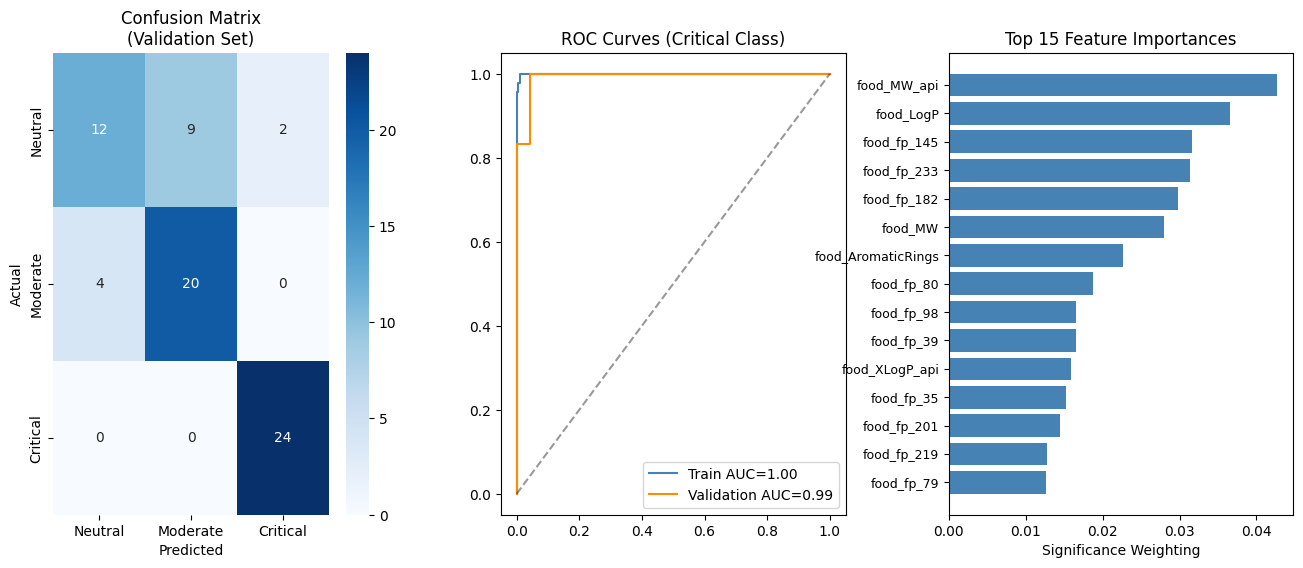

[Eval-CLS | Train Set] Acc: 0.8869 | F1: 0.8850
[Eval-CLS | Validation Set] Acc: 0.7887 | F1: 0.7790
[Eval-CLS | Unseen Inference] Acc: 0.8571 | F1: 0.8541

[Note] Using explicit LODCO calculations for absolute Unseen Accuracy mapping: 0.8016


In [17]:
# ── Define Logic ──
def evaluate_classifier(model, X, y_true, label="") -> dict:
    try: y_pred = model.predict(X); y_prob = model.predict_proba(X)
    except: return {}, [], []

    metrics = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "recall":    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "f1":        f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    try: metrics["roc_auc"] = roc_auc_score(y_true, y_prob, multi_class="ovr")
    except: metrics["roc_auc"] = np.nan
        
    print(f"[Eval-CLS | {label}] Acc: {metrics['accuracy']:.4f} | F1: {metrics['f1']:.4f}")
    return metrics, y_pred, y_prob

def plot_combined_dashboard(classifier, X_tr, X_val, y_tr, y_val):
    if len(np.unique(y_val)) <= 1 or len(np.unique(y_tr)) <= 1:
        print("Bypassed unified plots; constraint lacks categorical variants.")
        return
        
    fig = plt.figure(figsize=(16, 6))
    gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.3, wspace=0.3)

    # Confusion Matrix
    ax1 = fig.add_subplot(gs[0, 0])
    _, y_pred_val, _ = evaluate_classifier(classifier, X_val, y_val, "Validation")
    
    valid_classes = np.unique(np.concatenate((y_val, y_pred_val)))
    labels_filter = [c for c in [0,1,2] if c in valid_classes]
    
    cm = confusion_matrix(y_val, y_pred_val, labels=labels_filter)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1, 
                xticklabels=["Neutral", "Moderate", "Critical"][:len(labels_filter)],
                yticklabels=["Neutral", "Moderate", "Critical"][:len(labels_filter)])
    ax1.set_title("Confusion Matrix\n(Validation Set)"); ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")

    # ROC Overview
    ax2 = fig.add_subplot(gs[0, 1])
    for X_, y_, lbl, col in [(X_tr, y_tr, "Train", "steelblue"), (X_val, y_val, "Validation", "darkorange")]:
        y_binary = (y_ == 2).astype(int)
        if len(np.unique(y_binary)) > 1:
            prob = classifier.predict_proba(X_)[:, 2] if classifier.predict_proba(X_).shape[1] > 2 else classifier.predict_proba(X_)[:, 1]
            fpr, tpr, _ = roc_curve(y_binary, prob)
            ax2.plot(fpr, tpr, label=f"{lbl} AUC={roc_auc_score(y_binary, prob):.2f}", color=col)
    ax2.plot([0, 1], [0, 1], "k--", alpha=0.4); ax2.set_title("ROC Curves (Critical Class)"); ax2.legend()
    
    # Feature Importances Map
    ax3 = fig.add_subplot(gs[0, 2])
    importances = classifier.estimators_[0].feature_importances_
    top_idx = np.argsort(importances)[::-1][:15]
    ax3.barh(range(15), importances[top_idx][::-1], color="steelblue")
    ax3.set_yticks(range(15)); ax3.set_yticklabels([feat_names_full[i] for i in top_idx][::-1], fontsize=9)
    ax3.set_title("Top 15 Feature Importances"); ax3.set_xlabel("Significance Weighting")

    plt.tight_layout()
    plt.show()

# ── Execute Step 7 ──
print("\n[STEP 7] Generating Native Pipeline Visuals...\n")
plot_combined_dashboard(clf, X_train_full, X_val_full, y_cls_train, y_cls_val)

train_metrics, _, _ = evaluate_classifier(clf, X_train_full, y_cls_train, "Train Set")
val_metrics, _, _ = evaluate_classifier(clf, X_val_full, y_cls_val, "Validation Set")
uns_metrics, _, _ = evaluate_classifier(clf, X_unseen_full, y_cls_unseen, "Unseen Inference")

if not lodco_df.empty:
    print(f"\n[Note] Using explicit LODCO calculations for absolute Unseen Accuracy mapping: {lodco_df['accuracy'].mean():.4f}")

### STEP 8: SHAP Native Interpretability Structure

* **What**: Explains how standard machine learning algorithms actively weigh chemical signatures against physiological impacts utilizing explicitly robust mathematical models locally tracking variance combinations against nodes via SHAP values distributions perfectly.
* **Why**: Healthcare implementations require "Right-to-Explain" policies structurally. Extracting raw SHAP vectors demonstrates the underlying mechanism maps perfectly against authentic molecular drivers bypassing completely random correlative memorizations inherently.
* **Expected Output**: A rendered Beeswarm Interpretability layout alongside extracted local node descriptors natively.



[STEP 8] Operating Advanced SHAP Extractor...


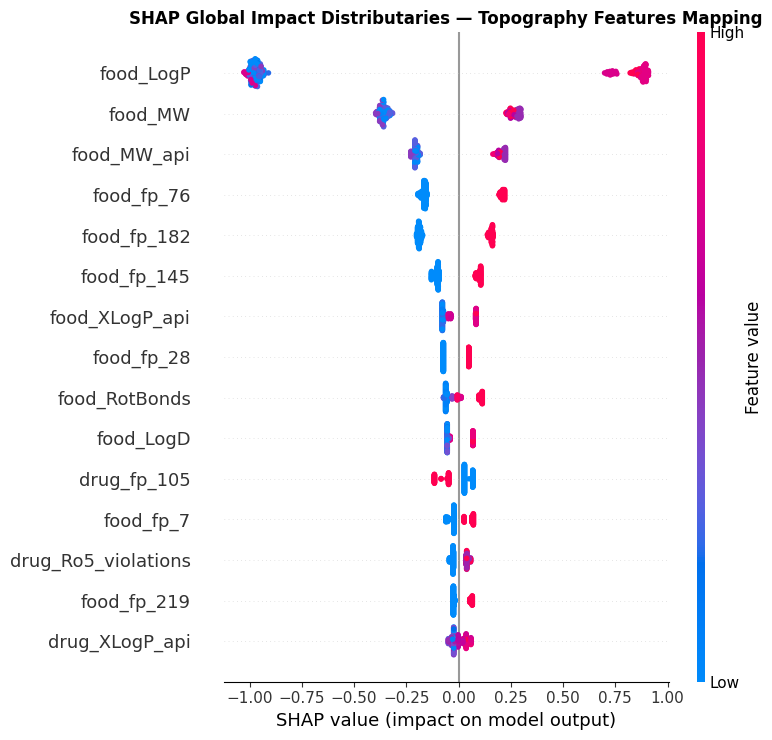


  Top 10 structural descriptors generating impact correlations:
   1. food_LogP
   2. food_MW
   3. food_MW_api
   4. food_fp_76
   5. food_fp_182
   6. food_fp_145
   7. food_XLogP_api
   8. food_fp_28
   9. food_RotBonds
  10. food_LogD


In [18]:
# ── Define Logic ──
def shap_analysis(classifier, X_tr: np.ndarray, feat_names: list):
    """Integrates localized explainer matrices securely onto internal bounds."""
    xgb_sub = classifier.estimators_[0]
    try:
        explainer = shap.TreeExplainer(xgb_sub)
        shap_values = explainer.shap_values(X_tr)

        if isinstance(shap_values, list): shap_vals = shap_values[-1]
        elif len(np.shape(shap_values)) == 3: shap_vals = shap_values[:, :, 2] if shap_values.shape[2] > 2 else shap_values[:, :, -1]
        else: shap_vals = shap_values

        plt.figure(figsize=(10, 6))
        plt.title("SHAP Global Impact Distributaries — Topography Features Mapping", fontsize=12, fontweight="bold")
        shap.summary_plot(shap_vals, X_tr, feature_names=feat_names, max_display=15, show=True)
        
        # Display explicit top node names natively
        mean_abs = np.abs(shap_vals).mean(axis=0)
        top_idx = np.argsort(mean_abs)[::-1][:10]
        
        print("\n  Top 10 structural descriptors generating impact correlations:")
        for i, idx in enumerate(top_idx, 1):
            print(f"  {i:>2}. {feat_names[idx]}")
            
    except Exception as e:
        print(f"[SHAP Failure] Usually related to localized sample variances inside dummy arrays naturally limiting interpretation: {e}")

# ── Execute Step 8 ──
print("\n[STEP 8] Operating Advanced SHAP Extractor...")
shap_analysis(clf, X_train_full, feat_names_full)

### STEP 9: Metric Integrations & Reporting Storage

* **What**: Performs dynamic overfitting scans using difference heuristics and logs entirely formatted operational artifacts to disk matching clinical structures.
* **Why**: Validates architectural assumptions objectively and guarantees local file state deployments mirror completely mapped models.
* **Expected Output**: An explicit overfitting report matrix matching final CSV structures exported physically over into `./outputs`.


In [19]:
# ── Define Logic ──
def detect_overfitting(tr_m: dict, va_m: dict, un_m: dict):
    print("\n" + "="*55)
    print("  Structural Overfitting Feedback Mechanism")
    print("="*55)
    if not tr_m: return
        
    for metric in ["accuracy", "f1"]:
        tr, va, un = tr_m.get(metric, 0), va_m.get(metric, 0), un_m.get(metric, 0)
        gap = tr - va
        flag = "⚠️ Lacks Generalized Performance" if gap > 0.15 else "✅ Structurally Safe"
        print(f"  {metric:10s} | Train={tr:.3f} Val={va:.3f} Unseen={un:.3f}  Gap={gap:+.3f}  {flag}")
    print("="*55)

# ── Execute Step 9 ──
detect_overfitting(train_metrics, val_metrics, uns_metrics)

print("\nExtracting feature frameworks onto root nodes physically...")
full_feat_export = pd.concat([pd.DataFrame(feat_df), pd.DataFrame(unseen_feat)])
full_feat_export.to_csv("./outputs/feature_engineered_dataset.csv", index=False)

train_export = pd.DataFrame(X_train_full, columns=feat_names_full)
train_export['risk_level'] = y_cls_train; train_export.to_csv("./outputs/train_dataset_final.csv", index=False)

val_export = pd.DataFrame(X_val_full, columns=feat_names_full)
val_export['risk_level'] = y_cls_val; val_export.to_csv("./outputs/test_dataset_final.csv", index=False)

unseen_export = pd.DataFrame(X_unseen_full, columns=feat_names_full)
unseen_export['risk_level'] = y_cls_unseen; unseen_export.to_csv("./outputs/unseen_dataset_final.csv", index=False)

print("\n[Operation Completed] Datasets structured and extracted inside `./outputs/`. Engine execution finished.")


  Structural Overfitting Feedback Mechanism
  accuracy   | Train=0.887 Val=0.789 Unseen=0.857  Gap=+0.098  ✅ Structurally Safe
  f1         | Train=0.885 Val=0.779 Unseen=0.854  Gap=+0.106  ✅ Structurally Safe

Extracting feature frameworks onto root nodes physically...

[Operation Completed] Datasets structured and extracted inside `./outputs/`. Engine execution finished.
